##Step 1: Set Up Environment & Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

##Step 2: Collect Historical Data


In [ ]:
import yfinance as yf

ticker = "AAPL"  # change to any stock symbol
data = yf.download(ticker, start="2015-01-01", end="2025-01-01")
data.to_csv("stock_data.csv")
print(data.head())

/tmp/ipykernel_2067/2623051629.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.192602  24.659504  23.754466  24.648440  212818400
2015-01-05  23.511059  24.042132  23.325184  23.962471  257142000
2015-01-06  23.513279  23.772177  23.152590  23.575237  263188400
2015-01-07  23.842981  23.942557  23.610636  23.721276  160423600
2015-01-08  24.759085  24.816618  24.053199  24.170479  237458000


##Step 3: Exploratory Data Analysis (EDA)


Columns after flattening: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_7', 'MA_30', 'Daily_Return', 'Volatility']
Price        Close         High          Low         Open        Volume  \
count  2487.000000  2487.000000  2487.000000  2487.000000  2.487000e+03   
mean     94.483285    95.400408    93.463137    94.395229  1.155154e+08   
std      65.277246    65.869134    64.592277    65.197700  6.660154e+07   
min      20.565874    20.868643    20.367820    20.488469  2.323470e+07   
25%      35.722452    35.936575    35.502260    35.725928  7.062210e+07   
50%      66.393219    67.573653    65.248604    66.595997  9.913660e+07   
75%     150.539742   152.096543   148.617506   150.241209  1.406028e+08   
max     257.375610   258.448771   255.994450   256.550893  6.488252e+08   

Price         MA_7        MA_30  Daily_Return   Volatility  
count  2487.000000  2487.000000   2487.000000  2487.000000  
mean     94.211829    93.189501      0.001038     0.015574  
std      65.056022    64.

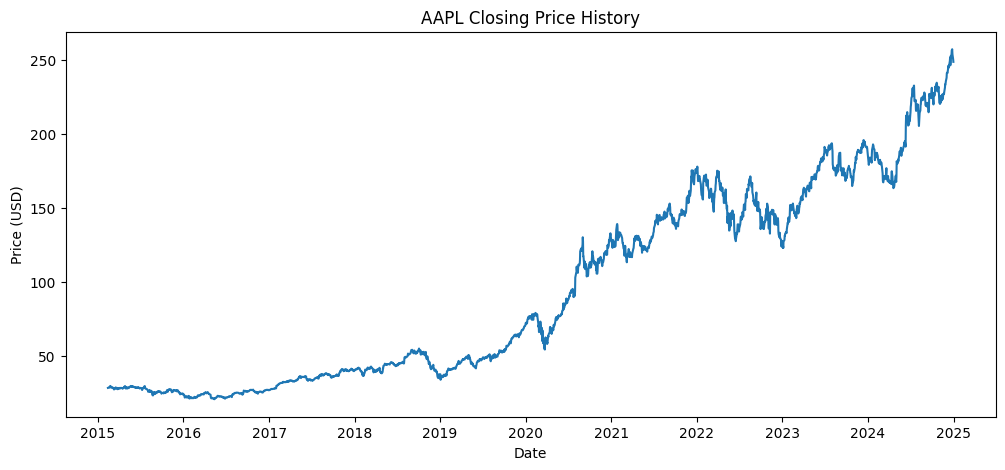

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten MultiIndex columns (fixes the empty dataframe issue)
data.columns = data.columns.get_level_values(0)
print("Columns after flattening:", data.columns.tolist())

print(data.describe())
print(data.isnull().sum())

plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title(f'{ticker} Closing Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

##Step 4: Feature Engineering

In [ ]:
data['MA_7'] = data['Close'].rolling(window=7).mean()
data['MA_30'] = data['Close'].rolling(window=30).mean()
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility'] = data['Daily_Return'].rolling(window=7).std()

print("Shape before dropna:", data.shape)
data.dropna(inplace=True)
print("Shape after first dropna:", data.shape)

data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True)
print("Shape after target dropna:", data.shape)

data.head()

Shape before dropna: (2487, 9)
Shape after first dropna: (2458, 9)
Shape after target dropna: (2457, 10)


Price,Close,High,Low,Open,Volume,MA_7,MA_30,Daily_Return,Volatility,Target
Date,,,,,,,,,,
2015-03-27,27.380459,27.702581,27.304927,27.673702,158184800,27.869837,28.250419,-0.007969,0.012214,28.073591
2015-03-30,28.073591,28.080256,27.547086,27.558194,188398800,27.833976,28.245161,0.025315,0.016876,27.642603
2015-03-31,27.642603,28.100239,27.627052,28.011377,168362400,27.787323,28.219984,-0.015352,0.017221,27.602621
2015-04-01,27.602621,27.795896,27.347144,27.729249,162485600,27.693385,28.186883,-0.001446,0.016414,27.840321
2015-04-02,27.840321,27.893637,27.589287,27.775896,128880400,27.649905,28.163705,0.008611,0.016996,28.291298


##Step 5: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_30', 'Volatility']
X = data[features]
y = data['Target']

print("X shape:", X.shape, "| y shape:", y.shape)  # sanity check — must NOT be 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

X shape: (2457, 8) | y shape: (2457,)
Train size: (1965, 8) | Test size: (492, 8)


####Step 6: Linear Regression Model

MSE: 6.61771336115978
MAE: 1.900022307666175
R2 Score: 0.9909083967926787


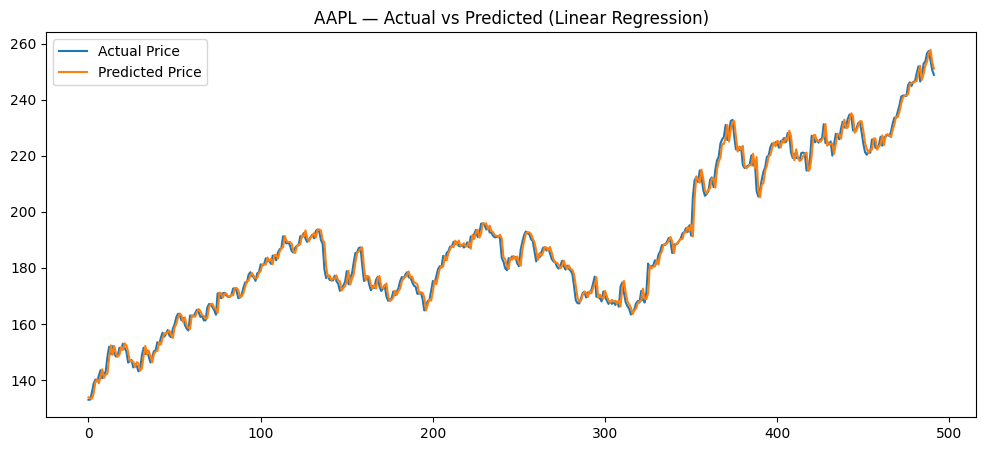

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.legend()
plt.title(f'{ticker} — Actual vs Predicted (Linear Regression)')
plt.show()

In [ ]:
def predict_from_user_input():
    print(f"Enter today's stock data for {ticker} to predict tomorrow's closing price:\n")

    open_price = float(input("Open price: "))
    high_price = float(input("High price: "))
    low_price = float(input("Low price: "))
    close_price = float(input("Close price: "))
    volume = float(input("Volume: "))

    # Recompute MA_7, MA_30, Volatility using recent historical data + new close
    recent_closes = list(data['Close'].tail(29)) + [close_price]  # last 29 + new one = 30 for MA_30
    ma_7 = np.mean(recent_closes[-7:])
    ma_30 = np.mean(recent_closes[-30:])

    recent_returns = list(data['Close'].pct_change().tail(6)) + [
        (close_price - data['Close'].iloc[-1]) / data['Close'].iloc[-1]
    ]
    volatility = np.std(recent_returns)

    input_df = pd.DataFrame([{
        'Open': open_price,
        'High': high_price,
        'Low': low_price,
        'Close': close_price,
        'Volume': volume,
        'MA_7': ma_7,
        'MA_30': ma_30,
        'Volatility': volatility
    }])[features]  # ensure same column order as training

    prediction = model.predict(input_df)
    print(f"\nPredicted next closing price: ${prediction[0]:.2f}")
    return prediction[0]

predict_from_user_input()

Enter today's stock data for AAPL to predict tomorrow's closing price:

Open price: 44
High price: 50
Low price: 40
Close price: 33
Volume: 1

Predicted next closing price: $46.06


np.float64(46.060171858008)